Boba Review Project 


The Yelp Open Dataset is a subset of Yelp data that is intended for educational use. It provides real-world data related to businesses including reviews, photos, check-ins, and attributes like hours, parking availability, and ambience.


In [5]:
#libaries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [6]:
BUSINESS_FILE = "/Volumes/Seagate/Yelp JSON/yelp_dataset/yelp_academic_dataset_business.json"

boba_businesses = []

for chunk in pd.read_json(
    BUSINESS_FILE,
    lines=True,
    chunksize=50000
):
    mask = (
        chunk["categories"]
        .fillna("")
        .str.contains("Bubble Tea", case=False, regex=False)
    )

    boba_businesses.append(chunk[mask])

boba_businesses = pd.concat(
    boba_businesses,
    ignore_index=True
)

print("Number of boba shops:", len(boba_businesses))

boba_businesses.head()

Number of boba shops: 477


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
1,bdfZdB2MTXlT6-RBjSIpQg,Pho Bistro,903 Embarcadero Del Norte,Isla Vista,CA,93117,34.412934,-119.855531,3.0,184,1,"{'RestaurantsDelivery': 'True', 'BikeParking':...","Food, Restaurants, Chinese, Bubble Tea, Vietna...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."
2,epGYbd0_OeSxsSkw-Kx5Rg,Hippie Hi,1814 Drew St,Clearwater,FL,33764,27.968452,-82.762159,4.0,16,0,"{'HasTV': 'True', 'RestaurantsReservations': '...","Vegan, Gluten-Free, Restaurants, Bubble Tea, S...","{'Monday': '10:0-20:0', 'Tuesday': '10:0-20:0'..."
3,i9eMSNpOA8BfHGZrM-9sZg,Kung Fu Tea,1469 Brace Rd,Cherry Hill,NJ,08034,39.889260,-75.015852,4.5,10,1,"{'WiFi': 'u'free'', 'RestaurantsTakeOut': 'True'}","Bubble Tea, Juice Bars & Smoothies, Food, Coff...","{'Monday': '10:0-21:0', 'Tuesday': '10:0-21:0'..."
4,-3-6BB10tIWNKGEF0Es2BA,The 81 Hong Kong Cafe,"625 E Wetmore Rd, Ste 109",Tucson,AZ,85705,32.288540,-110.963144,4.0,133,1,"{'Alcohol': 'u'none'', 'DogsAllowed': 'False',...","Coffee & Tea, Asian Fusion, Food, Bubble Tea, ...","{'Monday': '0:0-0:0', 'Wednesday': '10:0-21:0'..."


In [7]:
print(boba_businesses[
    ["name", "city", "state", "stars", "review_count"]
].head(20))

                                       name           city state  stars  \
0                        St Honore Pastries   Philadelphia    PA    4.0   
1                                Pho Bistro     Isla Vista    CA    3.0   
2                                 Hippie Hi     Clearwater    FL    4.0   
3                               Kung Fu Tea    Cherry Hill    NJ    4.5   
4                     The 81 Hong Kong Cafe         Tucson    AZ    4.0   
5                               Sweet Alley         Goleta    CA    4.0   
6                               Eleven Cafē         Tucson    AZ    5.0   
7                              Phamous Cafe         Goleta    CA    4.0   
8                                 Honeydeux    New Orleans    LA    3.5   
9                              Num Num Boba           Reno    NV    4.5   
10                          Bing's Boba Tea         Tucson    AZ    4.0   
11                                    HITEA   Chesterfield    MO    4.0   
12      Mint Modern Vietn

In [8]:
city_counts = (
    boba_businesses["city"]
    .value_counts()
    .head(15)
)

print(city_counts)

city
Philadelphia       97
Tampa              32
Edmonton           27
Tucson             24
Indianapolis       23
Nashville          16
Reno               14
Cherry Hill        13
Pinellas Park      12
Metairie           11
Goleta              9
Boise               9
St. Louis           9
King of Prussia     8
Isla Vista          7
Name: count, dtype: int64


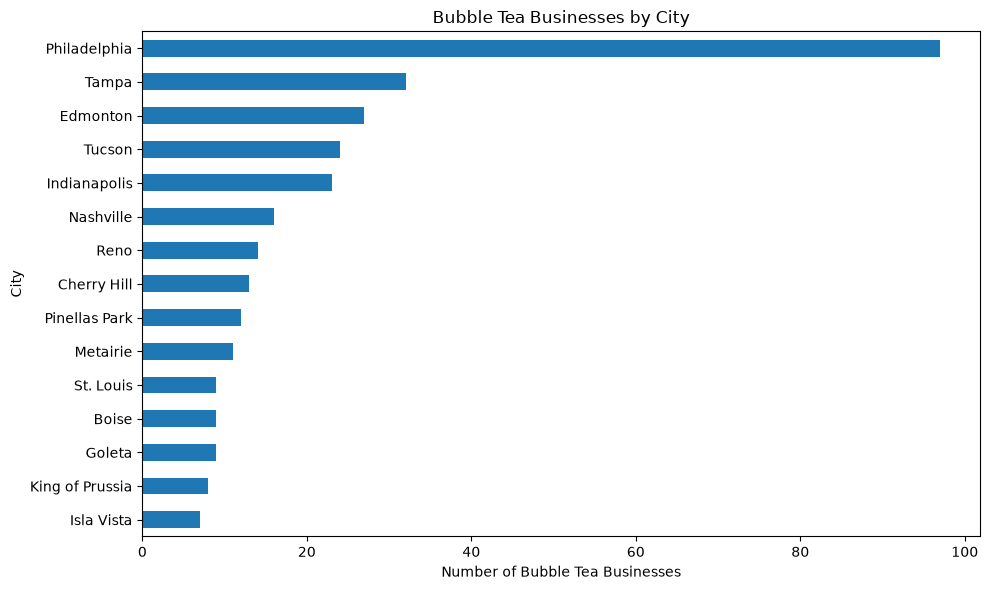

In [9]:
plt.figure(figsize=(10, 6))

city_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Bubble Tea Businesses")
plt.ylabel("City")
plt.title("Bubble Tea Businesses by City")

plt.tight_layout()
plt.show()

In [10]:
boba_ids = set(
    boba_businesses["business_id"]
)

print(len(boba_ids))

477


In [11]:
REVIEW_FILE = "/Volumes/Seagate/Yelp JSON/yelp_dataset/yelp_academic_dataset_review.json"

boba_reviews = []

for chunk in pd.read_json(
    REVIEW_FILE,
    lines=True,
    chunksize=100000
):

    matched = chunk[
        chunk["business_id"].isin(boba_ids)
    ]

    boba_reviews.append(matched)

boba_reviews = pd.concat(
    boba_reviews,
    ignore_index=True
)

print("Number of boba reviews:", len(boba_reviews))

boba_reviews.head()

Number of boba reviews: 39961


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,mRnYZes0nj4sr8DsE_gWMQ,FuTJWFYm4UKqewaosss1KA,fgTOJRkc703E4XRdcr5zRA,3,3,0,0,I've come from Cali where boba is very common ...,2016-01-30 01:59:11
1,e8u5K7rpzWt3CEoGmqYZNA,TkFfkUhNLczx5LB-uR9qaw,7EhTT4iEuA7JaaWA-eI3Qw,5,7,5,7,I really enjoy this little restaurant full of ...,2016-01-04 04:42:19
2,ndy1YoqgJ6BXsqPvFs9mkg,3Co7fpeBhUJGFJKbh1JAkw,B7nlRFe3EeQwAWpUpefGHA,3,0,0,0,Overpriced for what you get. I think this is a...,2017-08-28 22:34:34
3,bjBfJVb8Ikpz2Lbx-S-gyg,f3LI3ld5tNxXrMUU69v7wA,mcr1lAEdvGLMJhuPwI3I2A,5,0,0,0,Pleasantly surprised to find Taiwanese restaur...,2016-12-04 02:58:26
4,B-7TUHzZyMUsmt5dbUUxlw,RaC8QCJGJu0K3uPsDE0TKg,mcr1lAEdvGLMJhuPwI3I2A,5,1,0,1,In Reno for the night. Was a bit skeptical bec...,2015-01-04 04:40:12


In [12]:
boba_reviews.to_csv(
    "boba_reviews.csv",
    index=False
)

boba_businesses.to_csv(
    "boba_businesses.csv",
    index=False
)

In [13]:
boba_reviews = pd.read_csv(
    "boba_reviews.csv"
)

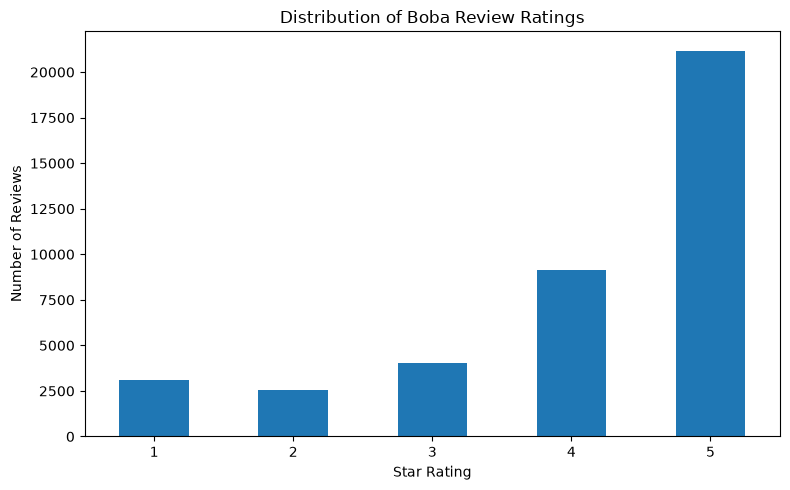

In [14]:
star_counts = (
    boba_reviews["stars"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

star_counts.plot(
    kind="bar"
)

plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Boba Review Ratings")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
reviews = boba_reviews[
    boba_reviews["stars"] != 3
].copy()

reviews["sentiment"] = reviews["stars"].apply(
    lambda x: 1 if x >= 4 else 0
)

In [16]:
print(
    reviews["sentiment"]
    .value_counts()
)

sentiment
1    30317
0     5625
Name: count, dtype: int64


In [17]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove unnecessary characters
    text = re.sub(
        r"[^a-z0-9\s!?']",
        " ",
        text
    )

    # Remove repeated whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


reviews["clean_text"] = (
    reviews["text"]
    .apply(clean_text)
)

In [18]:
X = reviews["clean_text"]
y = reviews["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5
)

In [20]:
X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)

In [21]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(
    X_train_tfidf,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [22]:
predictions = model.predict(
    X_test_tfidf
)

In [23]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.77      0.91      0.84      1125
    Positive       0.98      0.95      0.97      6064

    accuracy                           0.94      7189
   macro avg       0.88      0.93      0.90      7189
weighted avg       0.95      0.94      0.95      7189



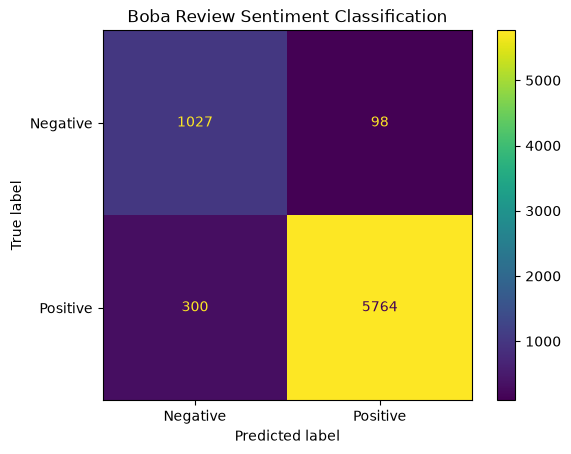

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

plt.title(
    "Boba Review Sentiment Classification"
)

plt.show()

In [25]:
feature_names = np.array(
    vectorizer.get_feature_names_out()
)

coefficients = model.coef_[0]


In [26]:
positive_indices = np.argsort(
    coefficients
)[-20:]

positive_words = pd.DataFrame({
    "term": feature_names[positive_indices],
    "coefficient": coefficients[positive_indices]
}).sort_values(
    "coefficient",
    ascending=False
)

print(positive_words)

           term  coefficient
19    delicious    11.162034
18        great     8.433748
17      amazing     7.869107
16         love     6.898624
15     favorite     6.664497
14         best     6.505239
13   definitely     6.149671
12      perfect     6.012176
11         good     5.459570
10    excellent     4.987496
9       awesome     4.959772
8         yummy     4.831437
7         loved     4.765762
6         fresh     4.608015
5      friendly     4.594952
4     fantastic     3.983251
3       enjoyed     3.861180
2    refreshing     3.763644
1          fast     3.657291
0   really good     3.634188


In [27]:
negative_indices = np.argsort(
    coefficients
)[:20]

negative_words = pd.DataFrame({
    "term": feature_names[negative_indices],
    "coefficient": coefficients[negative_indices]
}).sort_values(
    "coefficient"
)

print(negative_words)

             term  coefficient
0           worst    -6.662796
1   disappointing    -6.562242
2           bland    -6.179447
3    disappointed    -5.374188
4            rude    -5.111738
5        terrible    -5.040058
6        mediocre    -4.928409
7     tasted like    -4.800624
8        horrible    -4.694493
9      disgusting    -4.291317
10            bad    -4.239560
11         barely    -4.219830
12          awful    -4.119949
13     overpriced    -4.110312
14             ok    -4.064899
15          asked    -4.050847
16         wouldn    -3.957589
17           okay    -3.891750
18         watery    -3.822040
19           told    -3.809665


In [28]:
aspects = {

    "drink_quality": [
        "tea",
        "milk tea",
        "drink",
        "flavor",
        "fresh",
        "watery",
        "jasmine",
        "thai tea",
        "matcha"
    ],

    "toppings": [
        "boba",
        "pearls",
        "tapioca",
        "jelly",
        "popping boba",
        "grass jelly",
        "pudding"
    ],

    "sweetness": [
        "sweet",
        "sweetness",
        "sugar",
        "too sweet",
        "less sweet"
    ],

    "service": [
        "service",
        "staff",
        "employee",
        "employees",
        "cashier",
        "rude",
        "friendly"
    ],

    "wait_time": [
        "wait",
        "waiting",
        "slow",
        "minutes",
        "line",
        "busy"
    ],

    "price": [
        "price",
        "expensive",
        "cheap",
        "cost",
        "overpriced",
        "worth"
    ],

    "atmosphere": [
        "cute",
        "aesthetic",
        "decor",
        "atmosphere",
        "ambiance",
        "music",
        "seating"
    ]
}

In [29]:
def mentions_aspect(text, keywords):

    text = text.lower()

    return int(
        any(
            keyword in text
            for keyword in keywords
        )
    )


for aspect, keywords in aspects.items():

    reviews[aspect] = (
        reviews["clean_text"]
        .apply(
            lambda text:
            mentions_aspect(
                text,
                keywords
            )
        )
    )

In [30]:
reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,sentiment,clean_text,drink_quality,toppings,sweetness,service,wait_time,price,atmosphere
1,e8u5K7rpzWt3CEoGmqYZNA,TkFfkUhNLczx5LB-uR9qaw,7EhTT4iEuA7JaaWA-eI3Qw,5,7,5,7,I really enjoy this little restaurant full of ...,2016-01-04 04:42:19,1,i really enjoy this little restaurant full of ...,1,1,0,1,0,0,0
3,bjBfJVb8Ikpz2Lbx-S-gyg,f3LI3ld5tNxXrMUU69v7wA,mcr1lAEdvGLMJhuPwI3I2A,5,0,0,0,Pleasantly surprised to find Taiwanese restaur...,2016-12-04 02:58:26,1,pleasantly surprised to find taiwanese restaur...,1,1,0,0,0,0,0
4,B-7TUHzZyMUsmt5dbUUxlw,RaC8QCJGJu0K3uPsDE0TKg,mcr1lAEdvGLMJhuPwI3I2A,5,1,0,1,In Reno for the night. Was a bit skeptical bec...,2015-01-04 04:40:12,1,in reno for the night was a bit skeptical beca...,0,0,0,0,0,0,0
5,njO5cv6jDieJ9FFPN3DStg,GSKPa1JkF9UwfakvNyIv7A,5rryuz2myZJI0EfWtrTMxw,2,0,0,0,Waited 27 minutes for three teas (no one else ...,2018-01-21 17:12:54,0,waited 27 minutes for three teas no one else w...,1,0,0,0,1,1,0
7,IfjrWZaCo2MUgzjeXdvhLQ,UIXCajaEKgTiRCriAS8pmQ,7EhTT4iEuA7JaaWA-eI3Qw,5,2,1,1,This place is so cute. The interior is adorabl...,2012-03-30 04:23:31,1,this place is so cute the interior is adorable...,1,1,0,1,1,0,1


In [31]:
aspect_counts = {}

for aspect in aspects:

    aspect_counts[aspect] = (
        reviews[aspect].sum()
    )

aspect_counts = pd.Series(
    aspect_counts
).sort_values(
    ascending=False
)

print(aspect_counts)

drink_quality    23859
service          14574
toppings         10521
price             7370
wait_time         6923
sweetness         6755
atmosphere        5985
dtype: int64


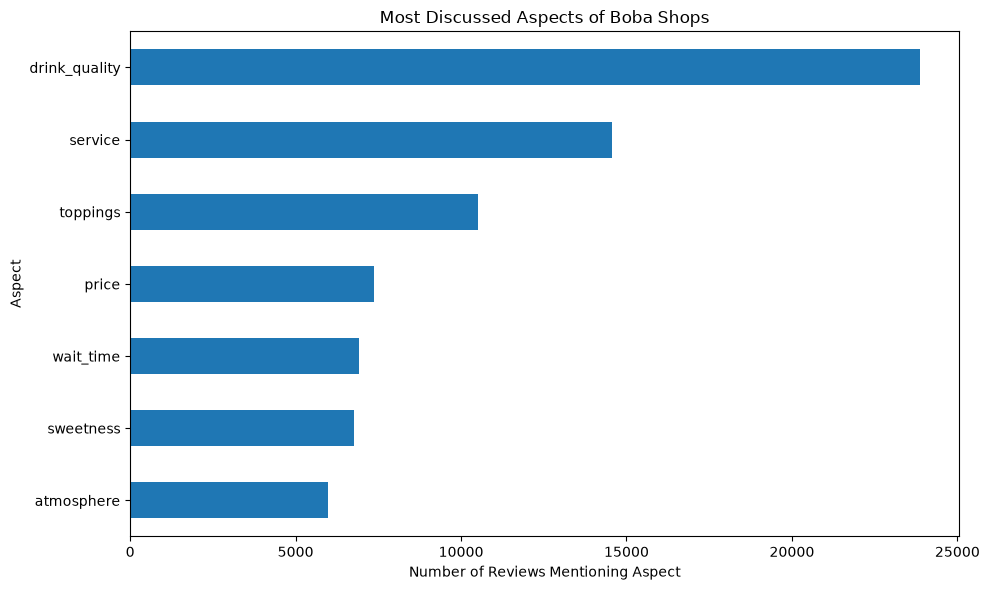

In [32]:
plt.figure(figsize=(10, 6))

aspect_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel(
    "Number of Reviews Mentioning Aspect"
)

plt.ylabel("Aspect")

plt.title(
    "Most Discussed Aspects of Boba Shops"
)

plt.tight_layout()

plt.show()

In [33]:
aspect_results = []

for aspect in aspects:

    subset = reviews[
        reviews[aspect] == 1
    ]

    positive_rate = (
        subset["sentiment"].mean()
    )

    aspect_results.append({
        "aspect": aspect,
        "reviews": len(subset),
        "positive_rate": positive_rate
    })


aspect_results = pd.DataFrame(
    aspect_results
)

aspect_results = aspect_results.sort_values(
    "positive_rate",
    ascending=False
)

print(aspect_results)

          aspect  reviews  positive_rate
6     atmosphere     5985       0.924311
2      sweetness     6755       0.879497
1       toppings    10521       0.865602
0  drink_quality    23859       0.861520
3        service    14574       0.843488
5          price     7370       0.828901
4      wait_time     6923       0.749386


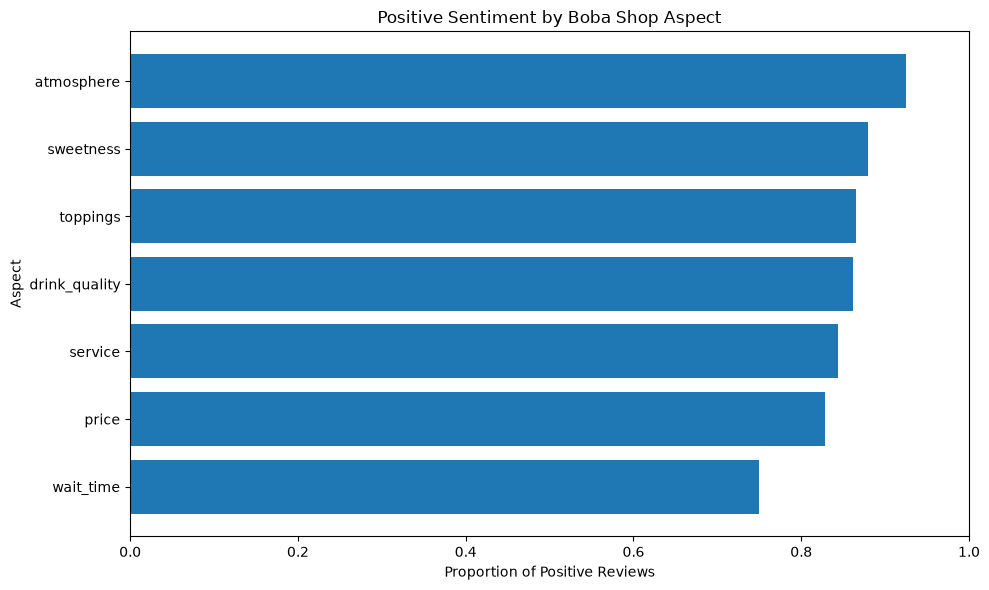

In [34]:
plot_data = aspect_results.sort_values(
    "positive_rate"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["aspect"],
    plot_data["positive_rate"]
)

plt.xlabel(
    "Proportion of Positive Reviews"
)

plt.ylabel("Aspect")

plt.title(
    "Positive Sentiment by Boba Shop Aspect"
)

plt.xlim(0, 1)

plt.tight_layout()

plt.show()

In [35]:
overall_positive_rate = (
    reviews["sentiment"].mean()
)

print(
    overall_positive_rate
)

0.8434978576595626


In [36]:
aspect_results[
    "difference_from_baseline"
] = (
    aspect_results["positive_rate"]
    - overall_positive_rate
)

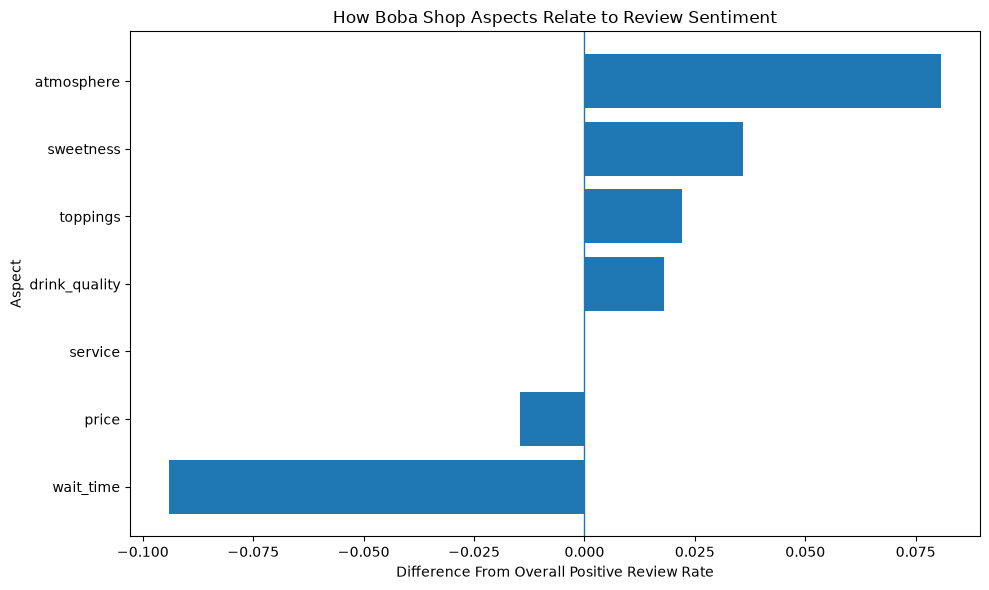

In [37]:
plot_data = aspect_results.sort_values(
    "difference_from_baseline"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["aspect"],
    plot_data["difference_from_baseline"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Difference From Overall Positive Review Rate"
)

plt.ylabel("Aspect")

plt.title(
    "How Boba Shop Aspects Relate to Review Sentiment"
)

plt.tight_layout()

plt.show()

In [38]:
import nltk

nltk.download("vader_lexicon")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/pegahtajvidi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/pegahtajvidi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pegahtajvidi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [39]:
from nltk.sentiment import (
    SentimentIntensityAnalyzer
)

from nltk.tokenize import sent_tokenize

sia = SentimentIntensityAnalyzer()

In [40]:
sia.polarity_scores(
    "The boba was perfectly chewy!"
)

{'neg': 0.0, 'neu': 0.471, 'pos': 0.529, 'compound': 0.6696}

In [41]:
aspect_sentiments = []

for review in reviews["text"]:

    sentences = sent_tokenize(
        str(review)
    )

    for sentence in sentences:

        clean_sentence = sentence.lower()

        score = sia.polarity_scores(
            sentence
        )["compound"]

        for aspect, keywords in aspects.items():

            if any(
                keyword in clean_sentence
                for keyword in keywords
            ):

                aspect_sentiments.append({
                    "aspect": aspect,
                    "sentence": sentence,
                    "sentiment_score": score
                })

In [42]:
aspect_sentiments = pd.DataFrame(
    aspect_sentiments
)

In [43]:
aspect_sentiment_summary = (
    aspect_sentiments
    .groupby("aspect")
    ["sentiment_score"]
    .agg(
        ["mean", "count"]
    )
    .sort_values(
        "mean",
        ascending=False
    )
)

print(
    aspect_sentiment_summary
)

                   mean  count
aspect                        
atmosphere     0.518907   6973
sweetness      0.459342   9505
service        0.445822  17691
drink_quality  0.335692  55360
price          0.332232   8815
toppings       0.325071  19091
wait_time      0.170527   9685
